In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/student_performance.csv")

df.head()

,StudyHours,Attendance,Assignments,PreviousScore,FinalScore
0,2,75,60,58,61
1,3,80,70,65,68
2,4,82,72,70,74
3,5,88,78,75,80
4,6,90,82,80,85


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   StudyHours     113 non-null    int64
 1   Attendance     113 non-null    int64
 2   Assignments    113 non-null    int64
 3   PreviousScore  113 non-null    int64
 4   FinalScore     113 non-null    int64
dtypes: int64(5)
memory usage: 4.5 KB


In [5]:
df.describe()

,StudyHours,Attendance,Assignments,PreviousScore,FinalScore
count,113.000000,113.000000,113.000000,113.000000,113.000000
mean,5.477876,83.362832,73.300885,70.309735,75.176991
std,2.777773,11.527964,16.328046,17.638270,17.600340
min,1.000000,60.000000,42.000000,38.000000,41.000000
25%,3.000000,74.000000,60.000000,56.000000,61.000000
50%,5.000000,85.000000,74.000000,71.000000,76.000000
75%,8.000000,94.000000,88.000000,85.000000,91.000000
max,10.000000,100.000000,100.000000,100.000000,100.000000


In [7]:
# Check missing values
df.isnull().sum()

StudyHours       0
Attendance       0
Assignments      0
PreviousScore    0
FinalScore       0
dtype: int64

In [8]:
# Check duplicate rows
df.duplicated().sum()

np.int64(1)

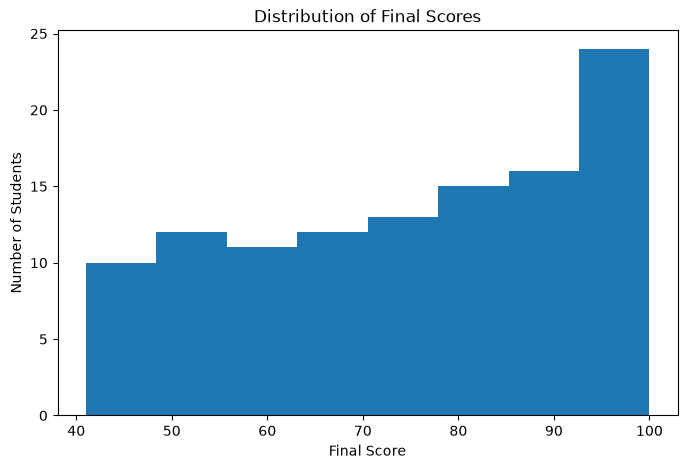

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["FinalScore"], bins=8)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()

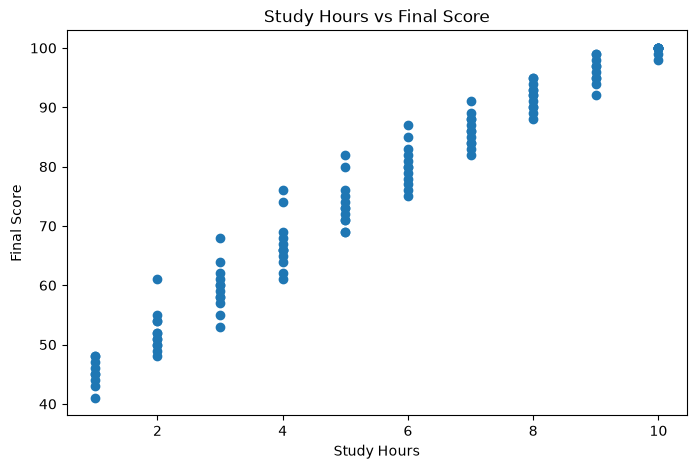

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(df["StudyHours"], df["FinalScore"])

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()

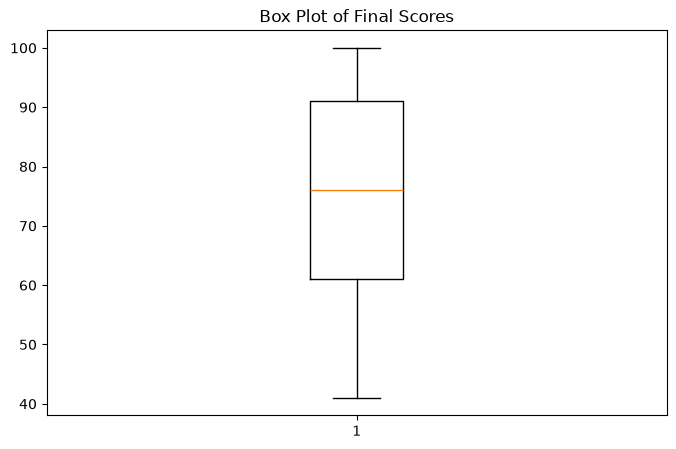

In [11]:
plt.figure(figsize=(8,5))

plt.boxplot(df["FinalScore"])

plt.title("Box Plot of Final Scores")

plt.show()

In [12]:
correlation = df.corr()

correlation

,StudyHours,Attendance,Assignments,PreviousScore,FinalScore
StudyHours,1.000000,0.969869,0.979906,0.979375,0.979873
Attendance,0.969869,1.000000,0.995114,0.994729,0.996804
Assignments,0.979906,0.995114,1.000000,0.998966,0.997064
PreviousScore,0.979375,0.994729,0.998966,1.000000,0.997543
FinalScore,0.979873,0.996804,0.997064,0.997543,1.000000


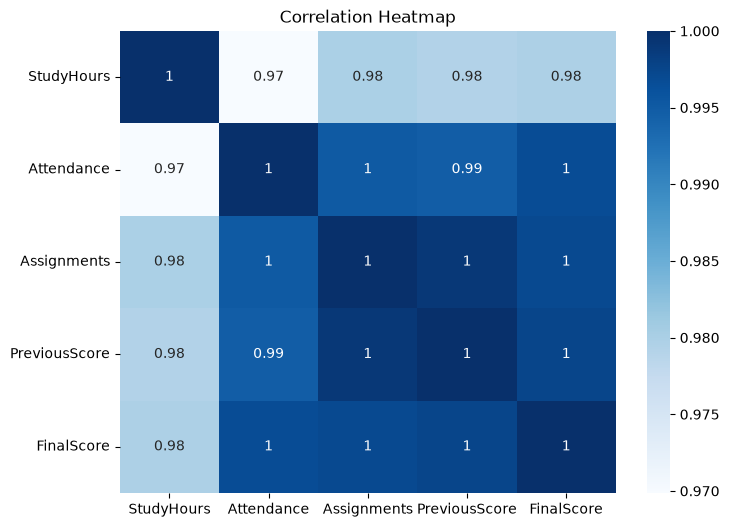

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

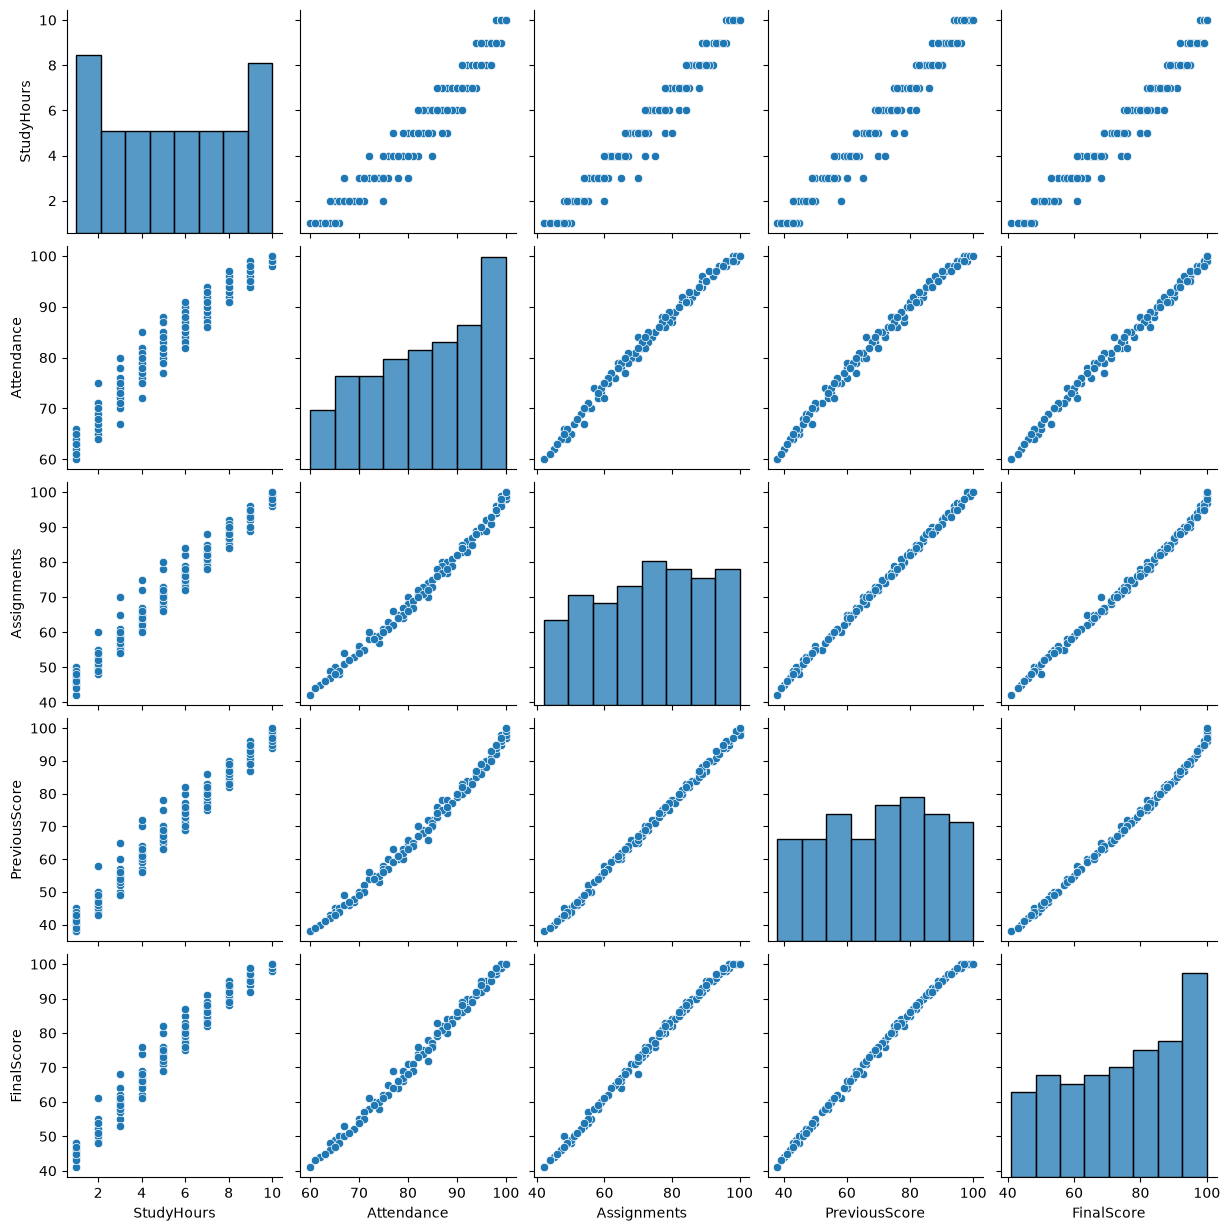

In [14]:
sns.pairplot(df)

plt.show()

In [15]:
average_score = df["FinalScore"].mean()

print("Average Final Score:", average_score)

Average Final Score: 75.17699115044248


In [16]:
highest = df["FinalScore"].max()

print("Highest Score:", highest)

Highest Score: 100


In [17]:
lowest = df["FinalScore"].min()

print("Lowest Score:", lowest)

Lowest Score: 41


In [18]:
df.corr()["FinalScore"].sort_values(ascending=False)

FinalScore       1.000000
PreviousScore    0.997543
Assignments      0.997064
Attendance       0.996804
StudyHours       0.979873
Name: FinalScore, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
# Features (Input)
X = df[["StudyHours", "Attendance", "Assignments", "PreviousScore"]]

# Target (Output)
y = df["FinalScore"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (90, 4)
Testing Data: (23, 4)


In [23]:
model = LinearRegression()

In [24]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.91, 0.81,-0.17, 0.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['StudyHours','Attendance','Assignments','PreviousScore']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-18.98
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [25]:
predictions = model.predict(X_test)

In [26]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results

,Actual,Predicted
80,93,93.541373
4,85,84.175404
40,84,82.984631
69,83,80.587901
10,76,75.620164
45,52,52.468131
70,89,87.920140
66,61,59.889917
47,66,66.321880
11,82,80.206698


In [27]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 0.7069011891959228
Mean Squared Error: 0.8215215750579625
R2 Score: 0.9972240219658282


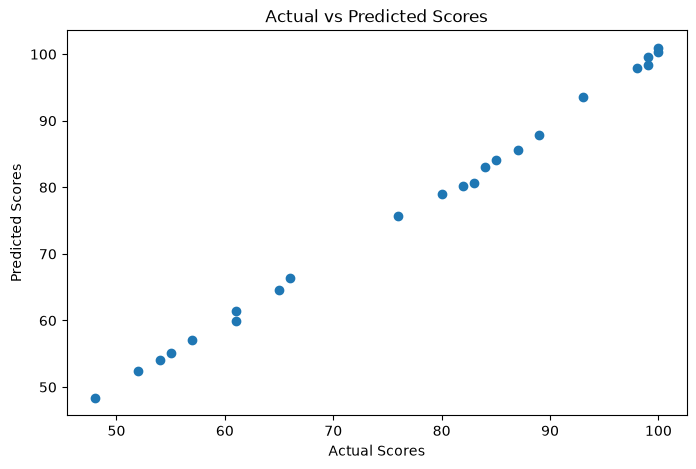

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")

plt.show()

In [29]:
new_student = [[6, 90, 85, 80]]

prediction = model.predict(new_student)

print("Predicted Final Score:", prediction[0])

Predicted Final Score: 83.65194232442427


c:\Users\My Notebook\Desktop\Student_Performance_Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import joblib

joblib.dump(model, "../model/model.pkl")

print("Model Saved Successfully!")

NameError: name 'model' is not defined

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
import pandas as pd

df = pd.read_csv("../data/student_performance.csv")

In [4]:
X = df[["StudyHours", "Attendance", "Assignments", "PreviousScore"]]
y = df["FinalScore"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = LinearRegression()

In [7]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.91, 0.81,-0.17, 0.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['StudyHours','Attendance','Assignments','PreviousScore']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-18.98
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [8]:
import os
import joblib

os.makedirs("../model", exist_ok=True)

joblib.dump(model, "../model/model.pkl")

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [9]:
loaded_model = joblib.load("../model/model.pkl")

In [10]:
prediction = loaded_model.predict([[5, 85, 80, 78]])

print(prediction)

[78.58523953]


c:\Users\My Notebook\Desktop\Student_Performance_Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
